# Figure 1. Standard TRK in noiseless and doubly noisy settings

Reproduces Figure 1 (§5.1.1–5.1.2) of *A Spectrally Damped Tensor Randomized
Kaczmarz Method for Doubly Noisy Tensor Systems*.

- **(a) Experiment 5.1.1** — noiseless convergence of standard TRK (`Fig1a.eps`)
- **(b) Experiment 5.1.2** — noise-limited behavior under doubly noisy perturbations (`Fig1b.eps`)

**Common setting.** All synthetic experiments use dimensions
$(n_1,n_2,n_3,n_4)=(20,10,5,5)$, and both experiments run **standard TRK**
(Ma & Molitor 2022): at step $t$, sample a row slice $i_t$ with probability
$p_{i}=\|\mathcal{A}_{i::}\|_F^2/\|\mathcal{A}\|_F^2$ and update

$$\mathcal{X}^{t+1}=\mathcal{X}^{t}-\mathcal{A}_{i_t::}^{*}\left(\mathcal{A}_{i_t::}\mathcal{A}_{i_t::}^{*}\right)^{-1}\left(\mathcal{A}_{i_t::}\mathcal{X}^{t}-\mathcal{B}_{i_t::}\right).$$

Both experiments start from $\mathcal{X}^0=\mathbf{0}$, run $1000$ iterations, and measure
the error against the noiseless target, $\|\mathcal{X}^t-\mathcal{X}^\star\|_F$, on a
semilogarithmic scale.

### Experiment 5.1.1 — Noiseless convergence of standard TRK

**Setup.** The entries of $\mathcal{A}\in\mathbb{R}^{20\times 10\times 5}$ and
$\mathcal{X}^\star\in\mathbb{R}^{10\times 5\times 5}$ are generated independently from the
standard Gaussian distribution, and $\mathcal{B}=\mathcal{A}\mathcal{X}^\star$, so the system
is consistent and $\mathcal{X}^\star$ solves it exactly.

**Expected result.** The error decays approximately linearly on the semilog scale,
confirming the expected linear convergence of standard TRK in the noiseless
consistent setting (iterating Theorem 3.1):

$$\mathbb{E}\,\|\mathcal{X}^t-\mathcal{X}^\star\|_F^2\le\left(1-\frac{\sigma_{\min}^2(\operatorname{bcirc}(\mathcal{A}))}{n_3\|\mathcal{A}\|_F^2}\right)^{t}\|\mathcal{X}^0-\mathcal{X}^\star\|_F^2.$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 1.2,        
    'xtick.major.width': 1.2,    
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.2,
    'ytick.minor.width': 1.2,
    'lines.linewidth': 1.5,
    'ps.fonttype': 42,
})

In [51]:
def t_prod(A, B):
    # t-product: FFT along mode 3 -> slice-wise matmul -> inverse FFT (Appendix A)
    n1, _, n3 = A.shape
    n4 = B.shape[1]
    A_hat = np.fft.fft(A, axis=2)
    B_hat = np.fft.fft(B, axis=2)
    C_hat = np.zeros((n1, n4, n3), dtype=complex)
    for k in range(n3):
        C_hat[:, :, k] = A_hat[:, :, k] @ B_hat[:, :, k]
    return np.fft.ifft(C_hat, axis=2).real


def t_transpose(A):
    # conjugate transpose: transpose each frontal slice, then reverse slices 2..n3
    n1, n2, n3 = A.shape
    At = np.zeros((n2, n1, n3), dtype=A.dtype)
    At[:, :, 0] = A[:, :, 0].T
    for k in range(1, n3):
        At[:, :, k] = A[:, :, n3 - k].T
    return At


def t_inv(tube):
    # tube inverse: reciprocal per Fourier frequency (nonzero by Assumption 2.9)
    hat = np.fft.fft(tube, axis=2)
    return np.fft.ifft(1.0 / hat, axis=2).real


def tnorm(T):
    # Frobenius norm of a tensor
    return np.linalg.norm(T.reshape(-1))


def trk_step(X, Aslice, Bslice):
    # standard TRK update: X <- X + A_i^* (A_i A_i^*)^{-1} (B_i - A_i X)
    resid = Bslice - t_prod(Aslice, X)
    At = t_transpose(Aslice)
    scale = t_inv(t_prod(Aslice, At))  # (A_i A_i^*)^{-1} is a 1x1xn3 tube
    return X + t_prod(At, t_prod(scale, resid))

In [52]:
n1, n2, n3, n4 = 20, 10, 5, 5
np.random.seed(42)

A = np.random.randn(n1, n2, n3)      # entries iid N(0, 1)
Xstar = np.random.randn(n2, n4, n3)  # ground truth
B = t_prod(A, Xstar)                 # exact right-hand side -> consistent system

# theorem-consistent sampling: p_i = ||A_i::||_F^2 / ||A||_F^2  (not uniform)
rowsq = np.array([tnorm(A[i:i+1])**2 for i in range(n1)])
prob = rowsq / rowsq.sum()

X = np.zeros((n2, n4, n3))  # X^0 = 0
niter = 1000
errors = []

for t in range(niter):
    i = np.random.choice(n1, p=prob)
    X = trk_step(X, A[i:i+1], B[i:i+1])
    errors.append(tnorm(X - Xstar))  # true error ||X^t - X*||_F

print(f"Initial Error: {errors[0]:.4f}, Final Error: {errors[-1]:.4e}")

Initial Error: 15.7182, Final Error: 2.1060e-04


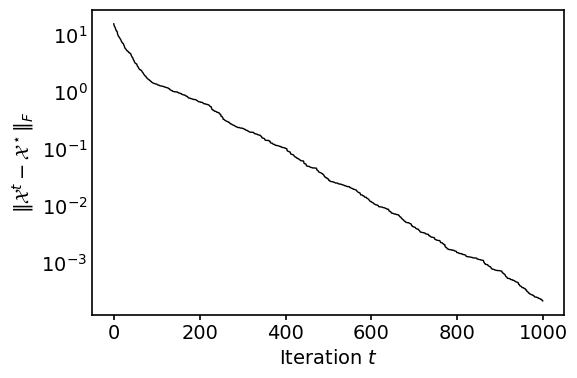

In [53]:
# semilog scale: a straight line = linear (geometric) convergence
plt.figure(figsize=(6, 4))
plt.semilogy(errors, linewidth=1, color='black')
plt.xlabel('Iteration $t$')
plt.ylabel(r'$\|\mathcal{X}^t-\mathcal{X}^\star\|_F$')
plt.gca().yaxis.set_minor_locator(mticker.NullLocator())
plt.tick_params(axis='y', which='both', length=0)
plt.tight_layout()
plt.savefig('Fig1a.eps', bbox_inches='tight')
plt.show()

### Experiment 5.1.2 — Noise-Limited Behavior of Standard TRK

**Setup.** The same noiseless tensors $\mathcal{A}$ and $\mathcal{X}^\star$ are perturbed according to

$$\tilde{\mathcal{A}}=\mathcal{A}+\delta_A\,\mathcal{G}_A,\qquad \tilde{\mathcal{B}}=\mathcal{B}+\delta_B\,\mathcal{G}_B,$$

where the entries of $\mathcal{G}_A,\mathcal{G}_B$ are i.i.d. standard Gaussian, with isotropic noise
levels $\delta_A=\delta_B\in\{0,\,10^{-4},\,10^{-2}\}$ ($\delta=0$ is the noiseless reference).
Standard TRK is applied to the observed system $\tilde{\mathcal{A}}\mathcal{X}=\tilde{\mathcal{B}}$,
one run per noise level, and the error is still measured against the noiseless target
$\mathcal{X}^\star$.

**Expected result.** The noiseless case keeps decreasing, while the noisy cases show an initial decay
followed by stabilization at nonzero error levels — the **semi-convergence** behavior showing that
standard TRK no longer converges to the exact solution under doubly noisy perturbations. This
motivates the stabilization mechanism of SD-TRK.

In [54]:
# doubly noisy model with delta_A = delta_B = delta
deltas = [0, 1e-4, 1e-2]

np.random.seed(42)                 # same noiseless A, X* as Experiment 5.1.1
Atrue = np.random.randn(n1, n2, n3)
Xstar = np.random.randn(n2, n4, n3)
Btrue = t_prod(Atrue, Xstar)

results = {}
for delta in deltas:
    if delta == 0:
        Anoisy, Bnoisy = Atrue.copy(), Btrue.copy()  # noiseless reference
    else:
        GA = np.random.randn(n1, n2, n3)             # A~ = A + delta*G_A
        GB = np.random.randn(n1, n4, n3)             # B~ = B + delta*G_B
        Anoisy = Atrue + delta * GA
        Bnoisy = Btrue + delta * GB

    # sampling probabilities come from the observed (noisy) tensor A~
    rowsq = np.array([tnorm(Anoisy[i:i+1])**2 for i in range(n1)])
    prob = rowsq / rowsq.sum()

    X = np.zeros((n2, n4, n3))
    hist = []
    for t in range(niter):
        i = np.random.choice(n1, p=prob)
        X = trk_step(X, Anoisy[i:i+1], Bnoisy[i:i+1])
        hist.append(tnorm(X - Xstar))  # error vs the noiseless target X*
    results[delta] = hist

    print(f"Initial Error: {hist[0]:.4f}, Final Error: {hist[-1]:.4e}")

Initial Error: 15.7182, Final Error: 2.1060e-04
Initial Error: 15.0818, Final Error: 2.0804e-03
Initial Error: 15.8847, Final Error: 2.0649e-01


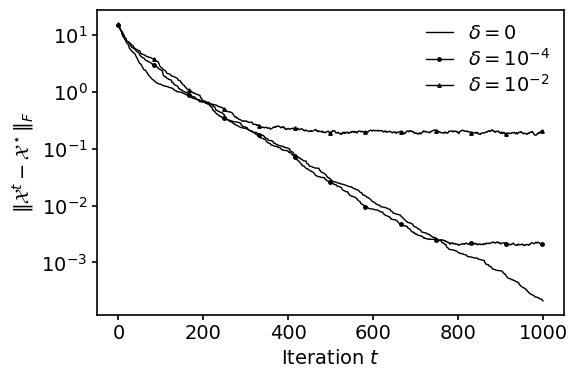

In [55]:
# semi-convergence: noisy curves decay first, then stall at a nonzero error floor
plt.figure(figsize=(6, 4))

styles = [
    dict(linestyle='-', linewidth=1.0, label=r'$\delta=0$'),
    dict(linestyle='-', marker='o', markevery=niter // 12, markersize=2.5,
         linewidth=1.0, label=r'$\delta=10^{-4}$'),
    dict(linestyle='-', marker='^', markevery=niter // 12, markersize=2.5,
         linewidth=1.0, label=r'$\delta=10^{-2}$'),
]

for delta, style in zip(deltas, styles):
    plt.semilogy(results[delta], color='black', **style)

plt.xlabel(r'Iteration $t$')
plt.ylabel(r'$\|\mathcal{X}^t-\mathcal{X}^\star\|_F$')
plt.gca().yaxis.set_minor_locator(mticker.NullLocator())
plt.legend(frameon=False, handlelength=1.4, labelspacing=0.25, borderpad=0.2)
plt.tight_layout()
plt.savefig('Fig1b.eps', bbox_inches='tight')
plt.show()